In [1]:
import pandas as pd
import numpy as np

In [3]:
dfSus=pd.read_csv("Ranking_unis - Foglio1.csv")
dfProf=pd.read_csv("8_Dataset finale.xlsx - Dataset 20-23.csv")

In [5]:
# first row containing the second-level labels
row0 = dfSus.iloc[0]

new_cols = []
current_main = None

for col, sub in zip(dfSus.columns, row0):
    
    # keep track of the latest non-Unnamed column
    if not str(col).startswith("Unnamed"):
        current_main = col
    
    # create combined name
    new_cols.append(f"{current_main}_{sub}")

# assign new column names
dfSus.columns = new_cols

# optionally remove the first row since it became headers
dfSus = dfSus.iloc[1:].reset_index(drop=True)

In [13]:
dfSus_clean=dfSus[dfSus["Identifiers_GLOBAL"].notna()]

In [14]:
# find all columns starting with "The_"
the_cols = [col for col in dfSus_clean.columns if col.startswith("The_")]

for col in the_cols:
    
    # split ranges like "70.8 - 80.5"
    split_vals = dfSus_clean[col].str.split(r"\s*-\s*", expand=True)
    
    # create float columns
    lower = pd.to_numeric(split_vals[0], errors="coerce")
    upper = pd.to_numeric(split_vals[1], errors="coerce")
    
    dfSus_clean[f"{col}_lower"] = lower
    dfSus_clean[f"{col}_upper"] = upper
    dfSus_clean[f"{col}_mean"] = (lower + upper) / 2

# optional: drop original range columns
dfSus_clean = dfSus_clean.drop(columns=the_cols)

/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_42275/1444925069.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfSus_clean[f"{col}_lower"] = lower
/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_42275/1444925069.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfSus_clean[f"{col}_upper"] = upper
/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_42275/1444925069.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usi

In [20]:
# columns to convert
cols_to_float = ["Identifiers_GLOBAL"] + [
    col for col in dfSus_clean.columns if col.startswith("UI Green Metrics_")
]

for col in cols_to_float:
    dfSus_clean[col] = (
        dfSus_clean[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
    )
    
    dfSus_clean[col] = pd.to_numeric(dfSus_clean[col], errors="coerce")

In [176]:
[x for x in dfSus_clean['Identifiers_UNIVERSITY_ID']]

['Bari',
 'Basilicata',
 'Bergamo',
 'Bologna',
 'Cagliari',
 'Camerino',
 'Chieti e Pescara',
 'Ferrara',
 'Firenze',
 'Foggia',
 'Genova',
 'Insubria',
 "L'Aquila",
 'Macerata',
 'Marche Politecnica',
 'Milano',
 'Milano Bicocca',
 'Milano Politecnico',
 'Modena e Reggio Emilia',
 'Padova',
 'Parma',
 'Piemonte Orientale',
 'Roma Tre',
 'Salerno',
 'Torino',
 'Torino Politecnico',
 'Tuscia',
 'Urbino',
 'Venezia Iuav']

In [23]:
# ---------- 1. Build proper column names ----------
row0 = dfProf.iloc[0]

new_cols = []
current_main = None

for col, sub in zip(dfProf.columns, row0):
    
    if not str(col).startswith("Unnamed"):
        current_main = col
    
    new_cols.append(f"{current_main}_{sub}")

dfProf.columns = new_cols

# remove header row
dfProf = dfProf.iloc[1:].reset_index(drop=True)


# ---------- 2. Convert numeric strings (European format) ----------
for col in dfProf.columns:
    
    # try conversion only for object/string columns
    if dfProf[col].dtype == "object":
        
        converted = (
            dfProf[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
        )
        
        dfProf[col] = pd.to_numeric(converted, errors="ignore")

# second pass: force truly numeric columns to float where possible
for col in dfProf.columns:
    dfProf[col] = pd.to_numeric(dfProf[col], errors="ignore")

/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_42275/1759918798.py:32: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  dfProf[col] = pd.to_numeric(converted, errors="ignore")
/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_42275/1759918798.py:32: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  dfProf[col] = pd.to_numeric(converted, errors="ignore")
/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_42275/1759918798.py:32: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  dfProf[col] = pd.to_numeric(converted, errors="ignore")
/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_42275/1759918798.py:32: FutureWarni

In [24]:
dfProf

,IDENTIFIERS_UNIVERSITY_ID,IDENTIFIERS_YEAR,STAFF_INTERNAL TEACHING STAFF,STAFF_AVERAGE AGE OF INTERNAL TEACHING STAFF,STAFF_FULL PROFESSORS,STAFF_AVERAGE AGE OF FULL PROFESSORS,STAFF_ASSOCIATE PROFESSOR,STAFF_AVERAGE AGE OF ASSOCIATE PROFESSORS,STAFF_TENURED RESEARCHERS,STAFF_AVERAGE AGE OF TENURED RESEARCHERS,...,ECONOMIC AND FINANCIAL_ECONOMIC AND FINANCIAL SUSTAINABILITY INDEX,ECONOMIC AND FINANCIAL_FFO (ANVUR),ECONOMIC AND FINANCIAL_FFO (DM),ECONOMIC AND FINANCIAL_BASE FUNDING QUOTA,ECONOMIC AND FINANCIAL_PERFORMANCE-BASED FUNDING QUOTA,ECONOMIC AND FINANCIAL_EQUALISATION INTERVENTIONS,ECONOMIC AND FINANCIAL_EXTRAORDINARY FUNDING PLANS,ECONOMIC AND FINANCIAL_STANDARD COST PER STUDENT,RESEARCH_HIGHLY CITED RESEARCHERS,RESEARCH_ARTICLES PUBLISHED IN NATURE AND SCIENCE
0,Bari,2020,1520,51.2,272,58.9,523,53.2,425,52.5,...,1.295140,0.0,179692122,117682112,46634445,7073805,8124512,7113,57,3
1,Bari Politecnico,2020,326,49.5,78,56.6,120,52.4,34,52.5,...,1.336507,0.0,41043094,27304719,11276408,141063,2317369,8334,21,2
2,Basilicata,2020,320,53.9,50,62.1,136,55.4,91,53.3,...,1.212724,0.0,30155605,17855887,9188640,781202,2310301,9059,9,0
3,Bergamo,2020,375,50.5,91,58.7,161,51.0,48,51.1,...,1.526342,0.0,55082751,38365377,15078631,0,3420748,5654,5,0
4,Bologna,2020,2850,51.2,771,57.6,1249,51.3,334,54.1,...,1.264252,0.0,374684109,225431066,118865396,5518552,24730817,6700,226,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,Udine,2023,692,53.3,166,60.1,306,54.0,98,57.0,...,1.182940,93041992.0,81999472,44642751,27125947,1173407,9054563,7483,41,2
240,Urbino,2023,367,53.5,80,60.0,161,54.1,46,58.6,...,1.312182,66660633.0,58396386,35794523,15628061,589260,6383134,6103,15,0
241,Venezia Cà Foscari,2023,714,49.8,182,57.7,302,51.2,27,56.8,...,1.217718,109510860.0,91946632,49887661,30745744,1062416,10248272,5554,24,2
242,Venezia Iuav,2023,179,52.6,48,59.9,78,53.6,6,62.8,...,1.289681,35425887.0,30016756,17139234,7939200,1744896,3189256,7974,4,0


In [31]:
dfSus_clean.head(1)

,Identifiers_UNIVERSITY_ID,Identifiers_GLOBAL,UI Green Metrics_SI,UI Green Metrics_EC,UI Green Metrics_WS,UI Green Metrics_WR,UI Green Metrics_TR,UI Green Metrics_ED,The_OVERALL_lower,The_OVERALL_upper,...,The_Life below water_mean,The_Life and land_lower,The_Life and land_upper,The_Life and land_mean,"The_Peace, justice and strong institutions_lower","The_Peace, justice and strong institutions_upper","The_Peace, justice and strong institutions_mean",The_Partnership for the goals_lower,The_Partnership for the goals_upper,The_Partnership for the goals_mean
0,Bari,6862.5,850,1275,1425,900.0,1400.0,1012.5,70.3,76.1,...,NaN,NaN,NaN,NaN,57.7,62.1,59.9,44.8,58.0,51.4


In [35]:
df = dfProf.copy()

# ensure year is numeric
df["IDENTIFIERS_YEAR"] = df["IDENTIFIERS_YEAR"].astype(int)

# keep only relevant years
df = df[df["IDENTIFIERS_YEAR"].isin([2020, 2021, 2022, 2023])]

In [ ]:
df = df.set_index(["IDENTIFIERS_UNIVERSITY_ID", "IDENTIFIERS_YEAR"])


In [38]:
numeric_cols = df.select_dtypes(include="number").columns
df_num = df[numeric_cols]

In [39]:
wide = df_num.unstack("IDENTIFIERS_YEAR")

In [40]:
base = 2023

result = pd.DataFrame(index=wide.index)

In [41]:
for col in numeric_cols:
    result[f"{col}_2023"] = wide[col][base]

In [42]:
result[f"{col}_1yr_change"] = wide[col][2023] - wide[col][2022]
result[f"{col}_2yr_change"] = wide[col][2023] - wide[col][2021]
result[f"{col}_3yr_change"] = wide[col][2023] - wide[col][2020]

In [43]:
result[f"{col}_acceleration"] = (
    (wide[col][2023] - wide[col][2022]) -
    (wide[col][2022] - wide[col][2021])
)

In [44]:
result = result.reset_index()

In [45]:
result

,IDENTIFIERS_UNIVERSITY_ID,STAFF_INTERNAL TEACHING STAFF_2023,STAFF_AVERAGE AGE OF INTERNAL TEACHING STAFF_2023,STAFF_FULL PROFESSORS_2023,STAFF_AVERAGE AGE OF FULL PROFESSORS _2023,STAFF_ASSOCIATE PROFESSOR _2023,STAFF_AVERAGE AGE OF ASSOCIATE PROFESSORS_2023,STAFF_TENURED RESEARCHERS_2023,STAFF_AVERAGE AGE OF TENURED RESEARCHERS_2023,STAFF_FIXED-TERM RESEARCHERS_2023,...,ECONOMIC AND FINANCIAL_PERFORMANCE-BASED FUNDING QUOTA_2023,ECONOMIC AND FINANCIAL_EQUALISATION INTERVENTIONS_2023,ECONOMIC AND FINANCIAL_EXTRAORDINARY FUNDING PLANS_2023,ECONOMIC AND FINANCIAL_STANDARD COST PER STUDENT_2023,RESEARCH_HIGHLY CITED RESEARCHERS _2023,RESEARCH_ARTICLES PUBLISHED IN NATURE AND SCIENCE _2023,RESEARCH_ARTICLES PUBLISHED IN NATURE AND SCIENCE _1yr_change,RESEARCH_ARTICLES PUBLISHED IN NATURE AND SCIENCE _2yr_change,RESEARCH_ARTICLES PUBLISHED IN NATURE AND SCIENCE _3yr_change,RESEARCH_ARTICLES PUBLISHED IN NATURE AND SCIENCE _acceleration
0,Bari,1575,50.9,313,58.3,660,52.9,208,55.6,394,...,61364933,4317746,19729828,6863,76,3,-2,0,0,-4
1,Bari Politecnico,402,47.9,117,56.3,127,51.9,13,54.5,145,...,15314102,577421,5442694,8299,35,2,-1,-1,0,-1
2,Basilicata,326,54.7,56,62.9,165,55.7,47,57.6,58,...,12202006,930511,4922067,8985,15,2,1,2,2,0
3,Bergamo,492,48.8,129,57.0,188,50.0,25,54.2,150,...,19811038,746979,7475929,5601,8,0,0,0,0,0
4,Bologna,3374,50.2,932,57.7,1435,51.3,178,57.3,829,...,150522065,5171645,41827363,6720,244,13,-6,4,1,-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,Udine,692,53.3,166,60.1,306,54.0,98,57.0,122,...,27125947,1173407,9054563,7483,41,2,0,1,2,-1
57,Urbino,367,53.5,80,60.0,161,54.1,46,58.6,80,...,15628061,589260,6383134,6103,15,0,0,0,-1,0
58,Venezia Cà Foscari,714,49.8,182,57.7,302,51.2,27,56.8,203,...,30745744,1062416,10248272,5554,24,2,-2,0,1,-4
59,Venezia Iuav,179,52.6,48,59.9,78,53.6,6,62.8,47,...,7939200,1744896,3189256,7974,4,0,0,0,0,0


In [46]:
dfFinal = dfSus_clean.merge(
    result,
    left_on="Identifiers_UNIVERSITY_ID",
    right_on="IDENTIFIERS_UNIVERSITY_ID",
    how="left"
)

In [74]:
# drop columns with fewer than 5 non-NaN values (in-place)
min_non_nan = 5

dfFinal = dfFinal.loc[:, dfFinal.notna().sum() >= min_non_nan]

In [75]:
corr = dfFinal.corr(numeric_only=True)

sustainability_cols = [
    col for col in corr.columns
    if col.startswith("UI Green Metrics_") or col.startswith("The_")
]

other_cols = [col for col in corr.columns if col not in sustainability_cols]

In [76]:
cross_corr = corr.loc[other_cols, sustainability_cols]

In [77]:
corr_pairs = cross_corr.unstack().dropna()

corr_pairs = corr_pairs.reset_index()
corr_pairs.columns = ["Sustainability_Metric", "Efficiency_Metric", "Correlation"]

In [78]:
top_positive = corr_pairs.sort_values("Correlation", ascending=False).head(50)

In [79]:
top_negative = corr_pairs.sort_values("Correlation", ascending=True).head(50)

In [80]:
print("TOP 50 POSITIVE CORRELATIONS")
display(top_positive)

print("TOP 50 NEGATIVE CORRELATIONS")
display(top_negative)

TOP 50 POSITIVE CORRELATIONS


,Sustainability_Metric,Efficiency_Metric,Correlation
2765,The_Sustainable cities and communities_lower,ECONOMIC AND FINANCIAL_OPERATING COSTS: DEPREC...,0.989502
2761,The_Sustainable cities and communities_lower,ECONOMIC AND FINANCIAL_OPERATING REVENUES: OTH...,0.976858
2875,The_Responsible consumption and production_lower,RESEARCH_ARTICLES PUBLISHED IN NATURE AND SCIE...,0.971894
2784,The_Sustainable cities and communities_lower,RESEARCH_HIGHLY CITED RESEARCHERS _2023,0.967032
2770,The_Sustainable cities and communities_lower,ECONOMIC AND FINANCIAL_TEACHING REVENUES: MAST...,0.962182
2846,The_Responsible consumption and production_lower,ECONOMIC AND FINANCIAL_NET EQUITY_2023,0.954638
2764,The_Sustainable cities and communities_lower,ECONOMIC AND FINANCIAL_OPERATING COSTS: CURREN...,0.951009
2742,The_Sustainable cities and communities_lower,POST LAUREAM EDUCATION_SECOND-LEVEL MASTER’S D...,0.950841
2717,The_Sustainable cities and communities_lower,STAFF_UNIVERSITY STAFF_2023,0.945879
2766,The_Sustainable cities and communities_lower,ECONOMIC AND FINANCIAL_OPERATING COSTS: OTHER_...,0.945410


TOP 50 NEGATIVE CORRELATIONS


,Sustainability_Metric,Efficiency_Metric,Correlation
1163,The_Qualitu Education_lower,ECONOMIC AND FINANCIAL_STANDARD COST PER STUDE...,-0.965976
1343,The_Qualitu Education_mean,ECONOMIC AND FINANCIAL_STANDARD COST PER STUDE...,-0.963206
1253,The_Qualitu Education_upper,ECONOMIC AND FINANCIAL_STANDARD COST PER STUDE...,-0.953239
3059,The_Climate Action_upper,RESEARCH_ARTICLES PUBLISHED IN NATURE AND SCIE...,-0.931169
3149,The_Climate Action_mean,RESEARCH_ARTICLES PUBLISHED IN NATURE AND SCIE...,-0.920093
2969,The_Climate Action_lower,RESEARCH_ARTICLES PUBLISHED IN NATURE AND SCIE...,-0.878808
2789,The_Sustainable cities and communities_lower,RESEARCH_ARTICLES PUBLISHED IN NATURE AND SCIE...,-0.803267
2638,The_Reducing inequalities_mean,STUDENT LIFECYCLE_PERCENTAGE OF GRADUATES SATI...,-0.793332
2548,The_Reducing inequalities_upper,STUDENT LIFECYCLE_PERCENTAGE OF GRADUATES SATI...,-0.793020
3413,"The_Peace, justice and strong institutions_mean",ECONOMIC AND FINANCIAL_STANDARD COST PER STUDE...,-0.781859


In [84]:
import matplotlib.pyplot as plt

/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_42275/3730013310.py:7: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


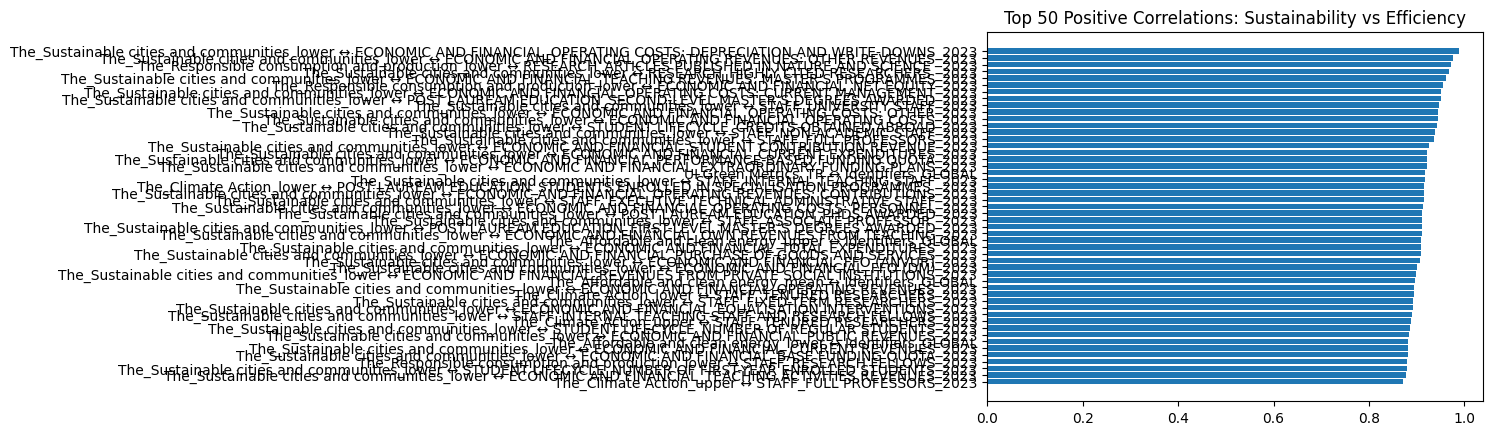

In [86]:
top_pos = corr_pairs.sort_values("Correlation", ascending=False).head(50)

plt.figure()
plt.barh(top_pos["Sustainability_Metric"] + " ↔ " + top_pos["Efficiency_Metric"], top_pos["Correlation"])
plt.title("Top 50 Positive Correlations: Sustainability vs Efficiency")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_42275/4253796151.py:7: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


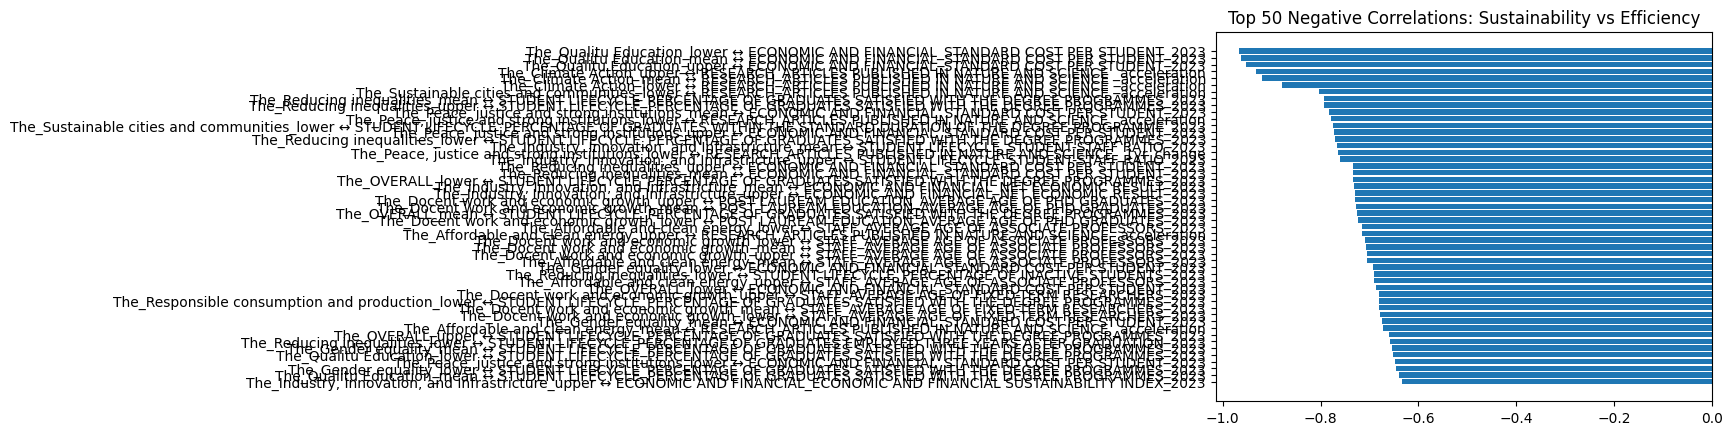

In [87]:
top_neg = corr_pairs.sort_values("Correlation", ascending=True).head(50)

plt.figure()
plt.barh(top_neg["Sustainability_Metric"] + " ↔ " + top_neg["Efficiency_Metric"], top_neg["Correlation"])
plt.title("Top 50 Negative Correlations: Sustainability vs Efficiency")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

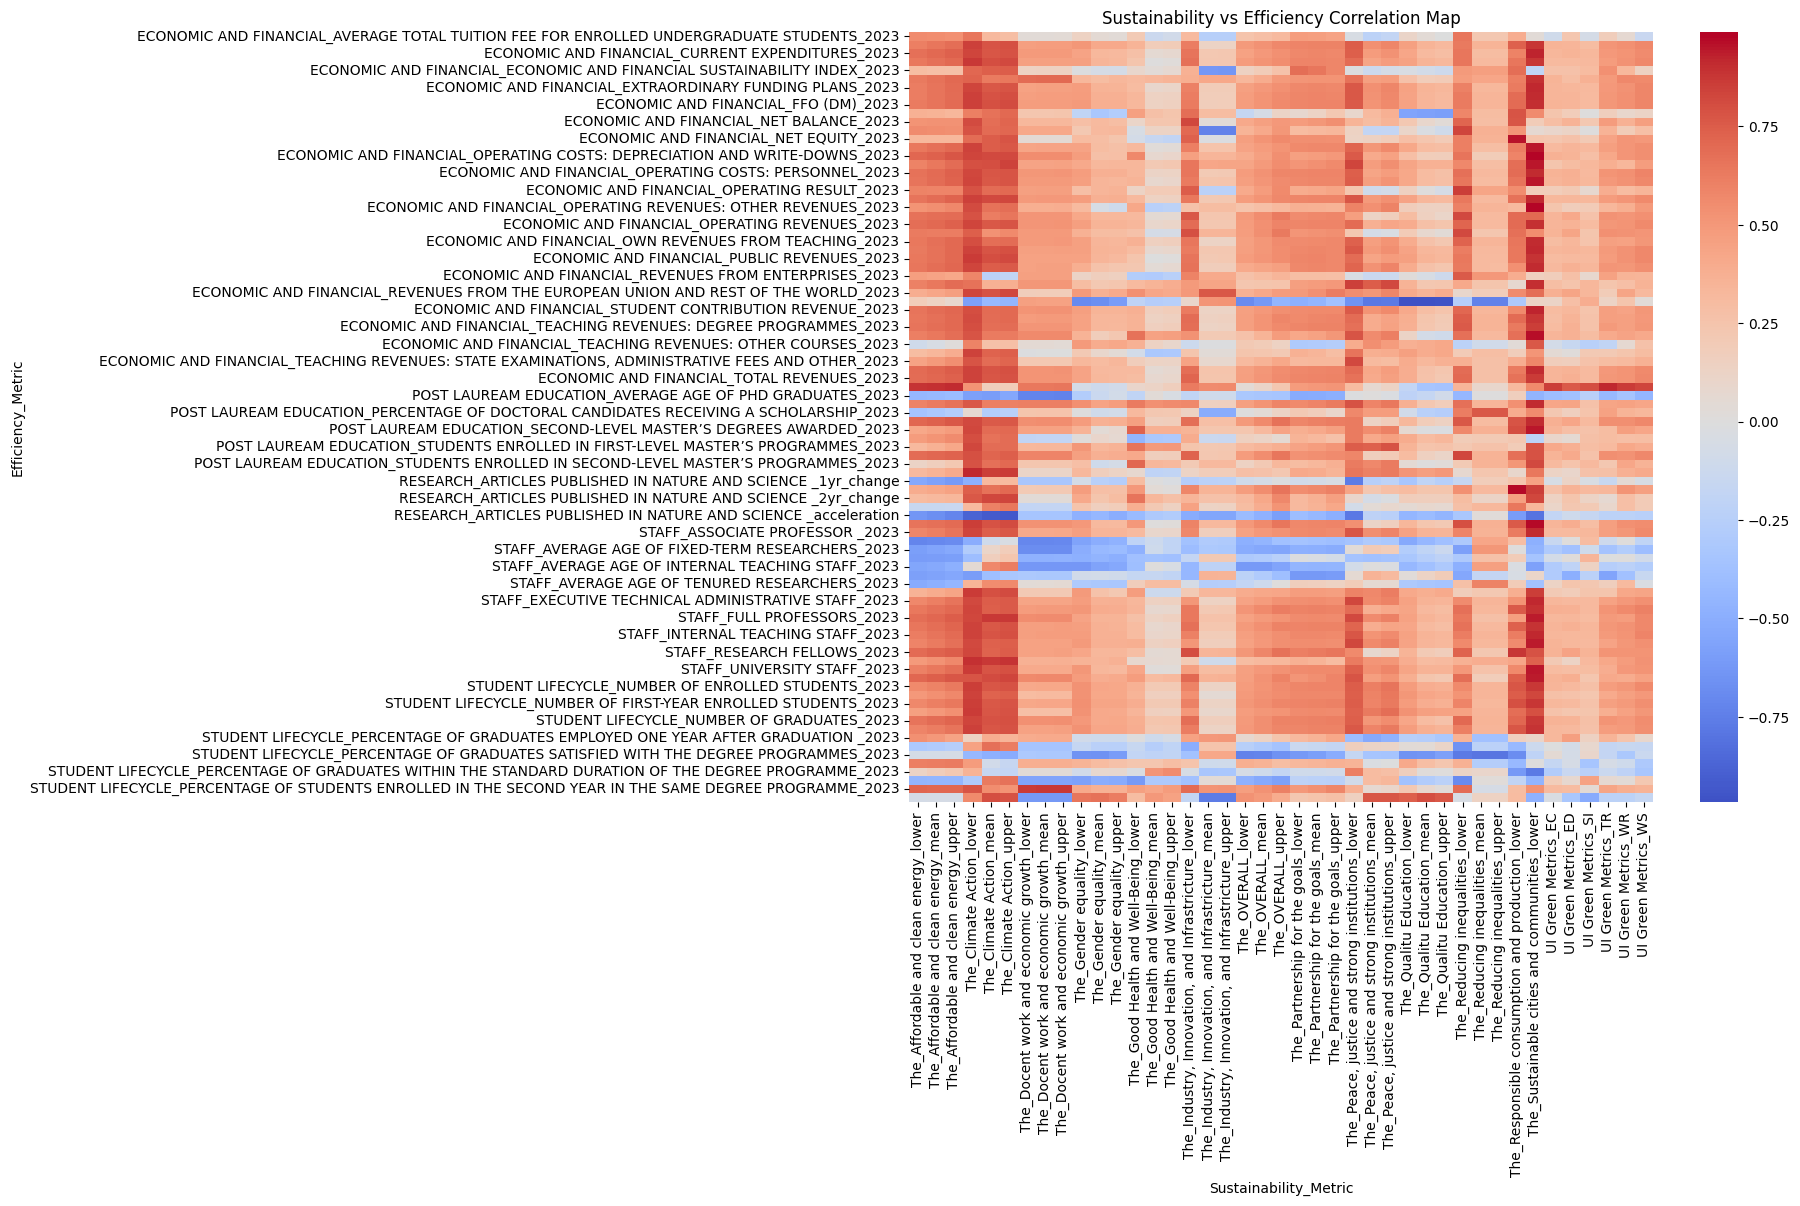

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = corr_pairs.pivot_table(
    index="Efficiency_Metric",
    columns="Sustainability_Metric",
    values="Correlation"
)

plt.figure(figsize=(12, 10))
sns.heatmap(pivot, cmap="coolwarm", center=0)
plt.title("Sustainability vs Efficiency Correlation Map")
plt.show()

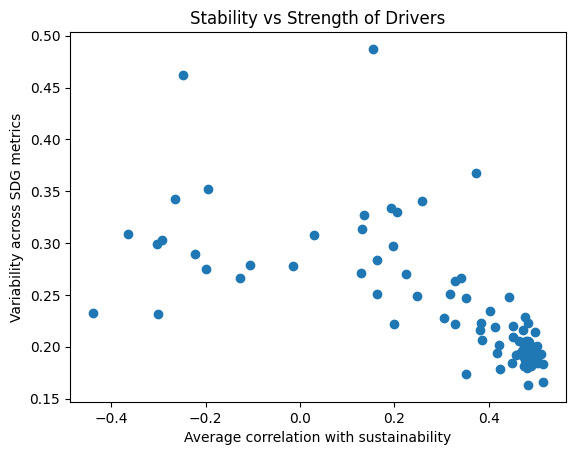

In [ ]:
# Interpretation:
### high mean + low std = strong universal driver
### high std = inconsistent driver

summary = corr_pairs.groupby("Efficiency_Metric")["Correlation"].agg(["mean", "std"]).reset_index()

plt.figure()
plt.scatter(summary["mean"], summary["std"])
plt.xlabel("Average correlation with sustainability")
plt.ylabel("Variability across SDG metrics")
plt.title("Stability vs Strength of Drivers")
plt.show()

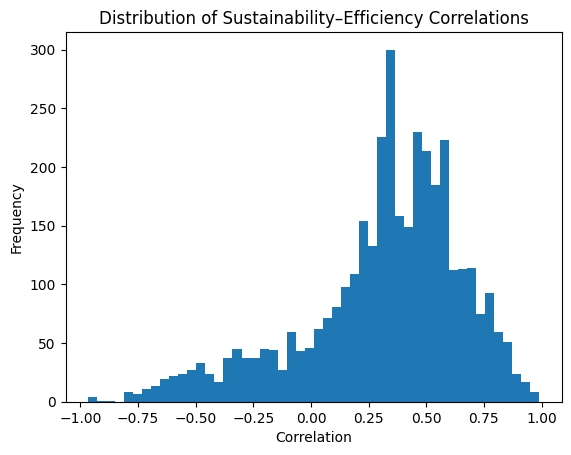

In [90]:
plt.figure()
plt.hist(corr_pairs["Correlation"], bins=50)
plt.title("Distribution of Sustainability–Efficiency Correlations")
plt.xlabel("Correlation")
plt.ylabel("Frequency")
plt.show()

/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_42275/4009446452.py:10: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


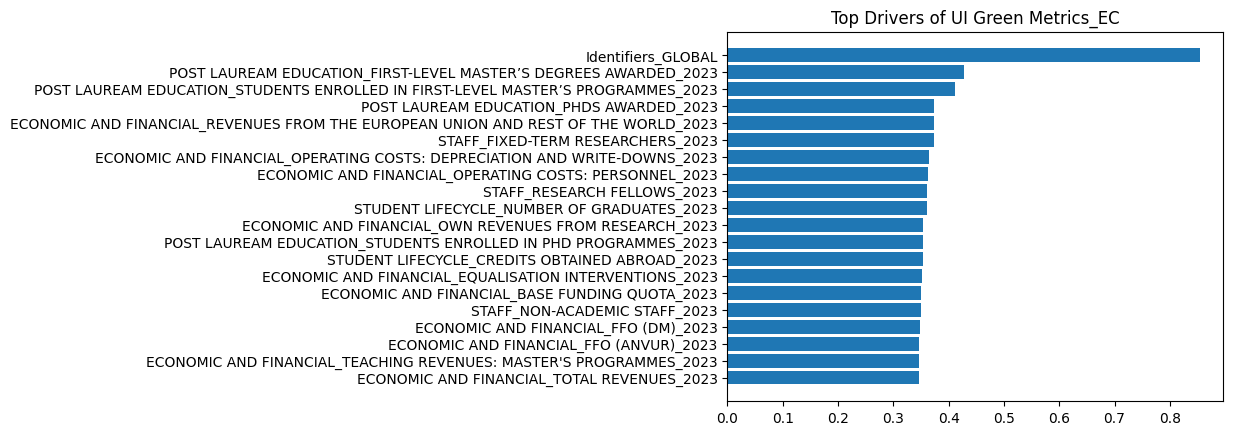

In [92]:
metric = "UI Green Metrics_EC"

subset = corr_pairs[corr_pairs["Sustainability_Metric"] == metric]
top = subset.sort_values("Correlation", ascending=False).head(20)

plt.figure()
plt.barh(top["Efficiency_Metric"], top["Correlation"])
plt.title(f"Top Drivers of {metric}")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [94]:
summary = (
    corr_pairs[corr_pairs["Efficiency_Metric"] != "Identifiers_GLOBAL"]
    .groupby("Efficiency_Metric")["Correlation"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

In [170]:
#Neg and pos
summary["driver_strength"] = summary["mean"] / (summary["std"] + 1e-6)
summary["driver_sign"] = np.sign(summary["mean"])
summary["abs_strength"] = summary["driver_strength"].abs()

In [135]:
top10_drivers = summary.sort_values("driver_score", ascending=False).head(10)
top10_drivers

,Efficiency_Metric,mean,std,count,driver_score
42,POST LAUREAM EDUCATION_FIRST-LEVEL MASTER’S DE...,0.515960,0.166114,41,3.106038
5,ECONOMIC AND FINANCIAL_EQUALISATION INTERVENTI...,0.482476,0.163105,41,2.958059
79,STUDENT LIFECYCLE_NUMBER OF GRADUATES_2023,0.514699,0.183516,41,2.804643
80,STUDENT LIFECYCLE_NUMBER OF REGULAR STUDENTS_2023,0.505373,0.184336,41,2.741577
75,STUDENT LIFECYCLE_NUMBER OF ENROLLED STUDENTS_...,0.498295,0.184074,41,2.707012
15,ECONOMIC AND FINANCIAL_OPERATING COSTS: OTHER_...,0.488533,0.180994,41,2.699147
77,STUDENT LIFECYCLE_NUMBER OF FIRST-YEAR ENROLLE...,0.500242,0.185344,41,2.698969
1,ECONOMIC AND FINANCIAL_BASE FUNDING QUOTA_2023,0.502995,0.187490,41,2.682773
70,STAFF_NON-ACADEMIC STAFF_2023,0.481397,0.179826,41,2.676999
8,ECONOMIC AND FINANCIAL_FFO (DM)_2023,0.500878,0.188610,41,2.655616


In [136]:
top10_names = top10_drivers["Efficiency_Metric"]

top10_detail = corr_pairs[
     corr_pairs["Efficiency_Metric"].isin(top10_names)
].copy()

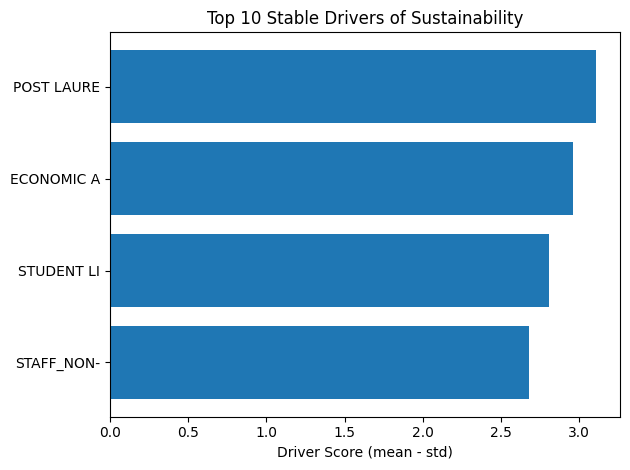

In [137]:
plt.figure()

plt.barh(
    top10_drivers["Efficiency_Metric"].str[:10],
    top10_drivers["driver_score"]
)

plt.xlabel("Driver Score (mean - std)")
plt.title("Top 10 Stable Drivers of Sustainability")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [138]:
[x for x in top10_drivers['Efficiency_Metric']]

['POST LAUREAM EDUCATION_FIRST-LEVEL MASTER’S DEGREES AWARDED_2023',
 'ECONOMIC AND FINANCIAL_EQUALISATION INTERVENTIONS_2023',
 'STUDENT LIFECYCLE_NUMBER OF GRADUATES_2023',
 'STUDENT LIFECYCLE_NUMBER OF REGULAR STUDENTS_2023',
 'STUDENT LIFECYCLE_NUMBER OF ENROLLED STUDENTS_2023',
 'ECONOMIC AND FINANCIAL_OPERATING COSTS: OTHER_2023',
 'STUDENT LIFECYCLE_NUMBER OF FIRST-YEAR ENROLLED STUDENTS_2023',
 'ECONOMIC AND FINANCIAL_BASE FUNDING QUOTA_2023',
 'STAFF_NON-ACADEMIC STAFF_2023',
 'ECONOMIC AND FINANCIAL_FFO (DM)_2023']

In [139]:
def shorten_metric(name):
    
    # split main parts
    parts = name.replace("_2023", "").split("_")
    
    # category + key concept
    if len(parts) >= 2:
        group = parts[0]
        metric = parts[1]
    else:
        return name[:15]
    
    # clean long phrases
    replacements = {
        "ECONOMIC AND FINANCIAL": "ECO_FIN",
        "STUDENT LIFECYCLE": "STUD",
        "POST LAUREAM EDUCATION": "POSTGRAD",
        "STAFF": "STAFF"
    }
    
    group = replacements.get(group, group[:6])
    
    # shorten metric intelligently
    metric = (
        metric.replace("NUMBER OF", "NUM")
              .replace("PERCENTAGE OF", "PCT")
              .replace("OPERATING COSTS", "OCOST")
              .replace("OPERATING REVENUES", "OREV")
              .replace("FUNDING QUOTA", "FUND")
              .replace("NON-ACADEMIC", "NONACAD")
              .replace("INTERNAL TEACHING STAFF", "TEACH")
              .replace("EXECUTIVE TECHNICAL ADMINISTRATIVE STAFF", "ADMIN")
              .replace("FIRST-YEAR ENROLLED STUDENTS", "1Y ENROL")
              .replace("ENROLLED STUDENTS", "ENROL")
              .replace("GRADUATES", "GRAD")
              .replace("RESEARCH", "RES")
              .replace("STAFF", "STF")
    )
    
    # final compact label
    return f"{group}:{metric}"[:40]

In [ ]:
def wrap_label(text, width=18):
    words = text.split(":")
    if len(words) == 1:
        words = text.split("_")
    
    lines = []
    current = ""
    
    for w in words:
        if len(current) + len(w) <= width:
            current += w + " "
        else:
            lines.append(current.strip())
            current = w + " "
    
    lines.append(current.strip())
    return "\n".join(lines)

In [162]:
labels = top10_drivers["Efficiency_Metric"].apply(shorten_metric).apply(wrap_label)

In [168]:
values = summary.sort_values("driver_strength", ascending=False).head(10)

strengths = values["driver_strength"].values
signs = values["driver_sign"].values

colors = [
    "green" if s > 0 else "red"
    for s in signs
]

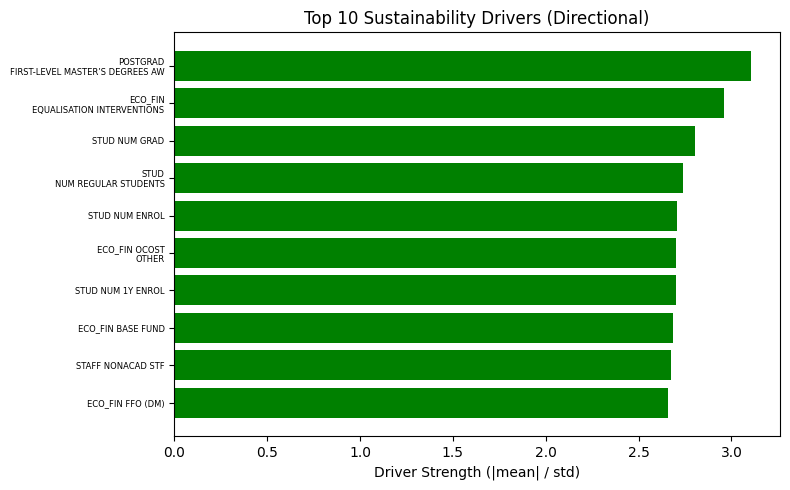

In [169]:
labels = values["Efficiency_Metric"].apply(shorten_metric).apply(wrap_label)

plt.figure(figsize=(8, 5))

plt.barh(
    labels,
    strengths,
    color=colors
)

plt.yticks(fontsize=6)
plt.xlabel("Driver Strength (|mean| / std)")
plt.title("Top 10 Sustainability Drivers (Directional)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

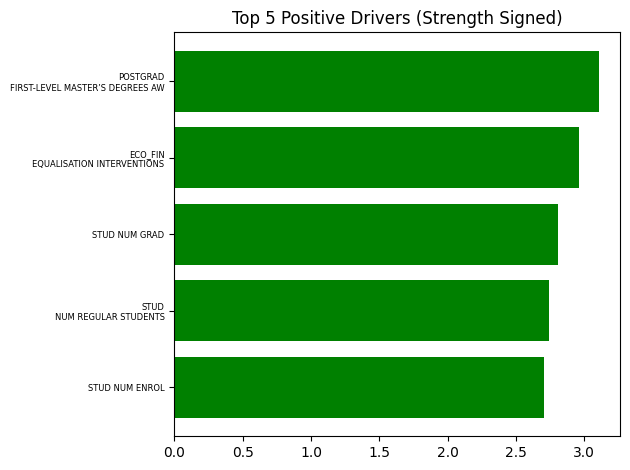

In [172]:
labels_pos = top5_positive["Efficiency_Metric"].apply(shorten_metric).apply(wrap_label)

plt.figure()

plt.barh(
    labels_pos,
    top5_positive["driver_strength"],
    color="green"
)

plt.yticks(fontsize=6)
plt.title("Top 5 Positive Drivers (Strength Signed)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

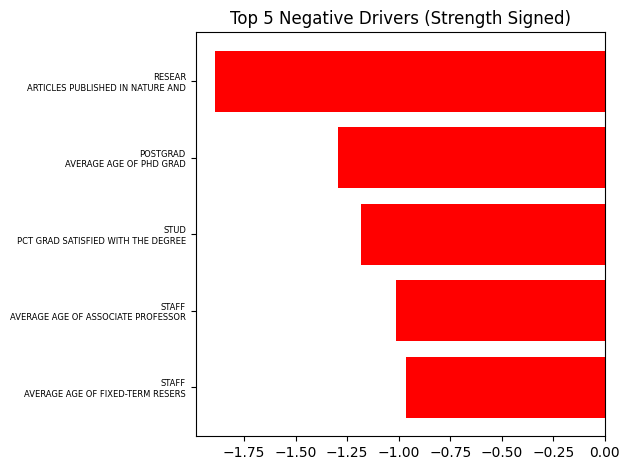

In [173]:
labels_neg = top5_negative["Efficiency_Metric"].apply(shorten_metric).apply(wrap_label)

plt.figure()

plt.barh(
    labels_neg,
    top5_negative["driver_strength"],
    color="red"
)

plt.yticks(fontsize=6)
plt.title("Top 5 Negative Drivers (Strength Signed)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [171]:
top5_positive = summary[summary["driver_strength"] > 0] \
    .sort_values("abs_strength", ascending=False) \
    .head(5)

top5_negative = summary[summary["driver_strength"] < 0] \
    .sort_values("abs_strength", ascending=False) \
    .head(5)

In [147]:
sustainability_cols = [
    col for col in dfFinal.columns
    if col.startswith("UI Green Metrics_") or col.startswith("The_")
]
dfFinal["SUSTAINABILITY_SCORE"] = dfFinal[sustainability_cols].mean(axis=1)

/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_42275/1767118089.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfFinal["SUSTAINABILITY_SCORE"] = dfFinal[sustainability_cols].mean(axis=1)


In [149]:
efficiency_cols = [
    col for col in dfFinal.columns
    if col.startswith("ECONOMIC AND FINANCIAL_")
    or col.startswith("STAFF_")
    or col.startswith("STUDENT LIFECYCLE_")
]
dfFinal["EFFICIENCY_SCORE"] = dfFinal[efficiency_cols].mean(axis=1)

/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_42275/488796985.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfFinal["EFFICIENCY_SCORE"] = dfFinal[efficiency_cols].mean(axis=1)


In [150]:
dfFinal["SUSTAINABILITY_SCORE"] = (
    dfFinal[sustainability_cols].mean(axis=1)
    .rank(pct=True)
)

dfFinal["EFFICIENCY_SCORE"] = (
    dfFinal[efficiency_cols].mean(axis=1)
    .rank(pct=True)
)

/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_42275/1505601143.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfFinal["SUSTAINABILITY_SCORE"] = (
/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_42275/1505601143.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfFinal["EFFICIENCY_SCORE"] = (


In [151]:
x_med = dfFinal["EFFICIENCY_SCORE"].median()
y_med = dfFinal["SUSTAINABILITY_SCORE"].median()

In [156]:
def classify(row):
    if row["EFFICIENCY_SCORE"] >= x_med and row["SUSTAINABILITY_SCORE"] >= y_med:
        return "High Eff / High Sust"
    elif row["EFFICIENCY_SCORE"] >= x_med:
        return "High Eff / Low Sust"
    elif row["SUSTAINABILITY_SCORE"] >= y_med:
        return "Low Eff / High Sust"
    else:
        return "Low Eff / Low Sust"

dfFinal["QUADRANT"] = dfFinal.apply(classify, axis=1)

/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_42275/1834292751.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfFinal["QUADRANT"] = dfFinal.apply(classify, axis=1)


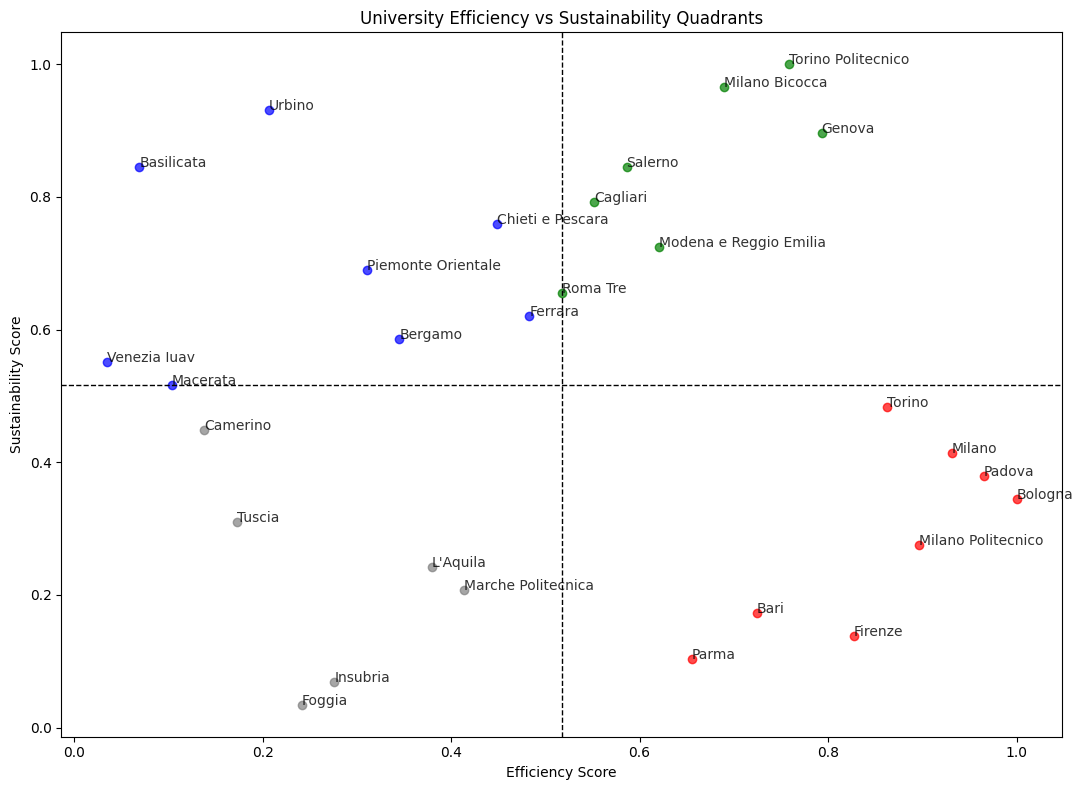

In [159]:
label_col = "Identifiers_UNIVERSITY_ID"
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 8))

colors = {
    "High Eff / High Sust": "green",
    "High Eff / Low Sust": "red",
    "Low Eff / High Sust": "blue",
    "Low Eff / Low Sust": "gray"
}

for q, color in colors.items():
    subset = dfFinal[dfFinal["QUADRANT"] == q]
    
    plt.scatter(
        subset["EFFICIENCY_SCORE"],
        subset["SUSTAINABILITY_SCORE"],
        c=color,
        label=q,
        alpha=0.7
    )

# quadrant lines
x_med = dfFinal["EFFICIENCY_SCORE"].median()
y_med = dfFinal["SUSTAINABILITY_SCORE"].median()

plt.axvline(x_med, linestyle="--", color="black", linewidth=1)
plt.axhline(y_med, linestyle="--", color="black", linewidth=1)

# labels
plt.xlabel("Efficiency Score")
plt.ylabel("Sustainability Score")
plt.title("University Efficiency vs Sustainability Quadrants")


for _, row in dfFinal.iterrows():
    plt.text(
        row["EFFICIENCY_SCORE"],
        row["SUSTAINABILITY_SCORE"],
        str(row[label_col]),
        fontsize=10,
        color="black",
        alpha=0.8
    )

plt.tight_layout()
plt.show()

In [174]:
for q in dfFinal["QUADRANT"].unique():
    print("\n" + "="*40)
    print(q)
    print("="*40)
    
    print(dfFinal[dfFinal["QUADRANT"] == q]["Identifiers_UNIVERSITY_ID"].tolist())


High Eff / Low Sust
['Bari', 'Bologna', 'Firenze', 'Milano', 'Milano Politecnico', 'Padova', 'Parma', 'Torino']

Low Eff / High Sust
['Basilicata', 'Bergamo', 'Chieti e Pescara', 'Ferrara', 'Macerata', 'Piemonte Orientale', 'Urbino', 'Venezia Iuav']

High Eff / High Sust
['Cagliari', 'Genova', 'Milano Bicocca', 'Modena e Reggio Emilia', 'Roma Tre', 'Salerno', 'Torino Politecnico']

Low Eff / Low Sust
['Camerino', 'Foggia', 'Insubria', "L'Aquila", 'Marche Politecnica', 'Tuscia']


In [177]:
summary["driver_score"] = summary["driver_strength"]

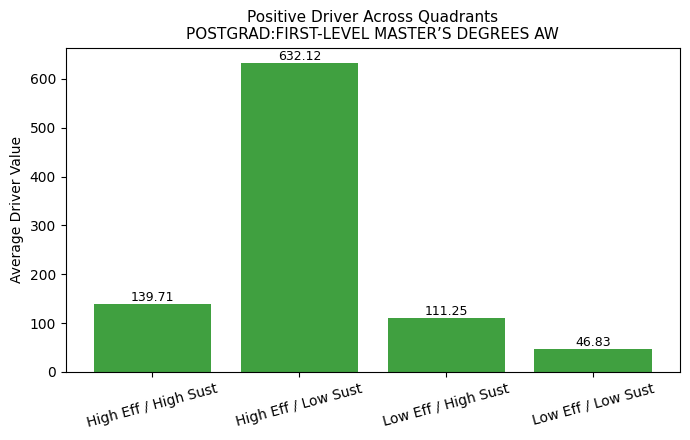

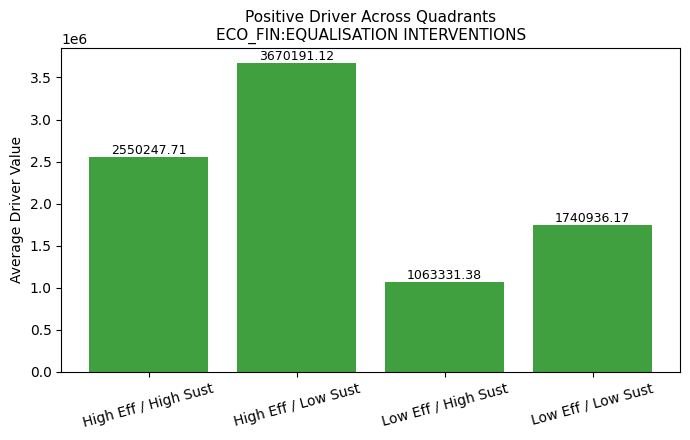

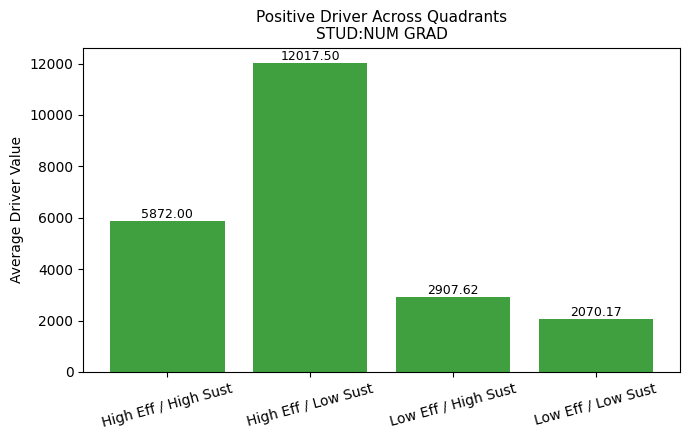

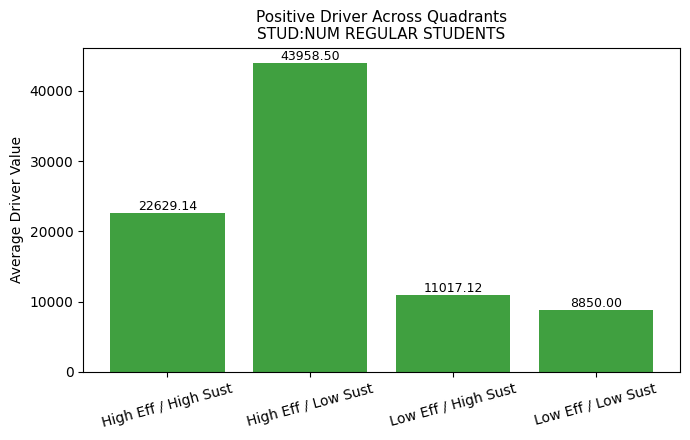

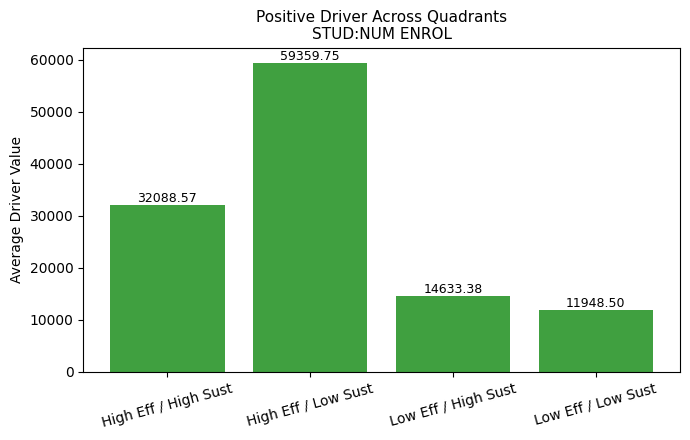

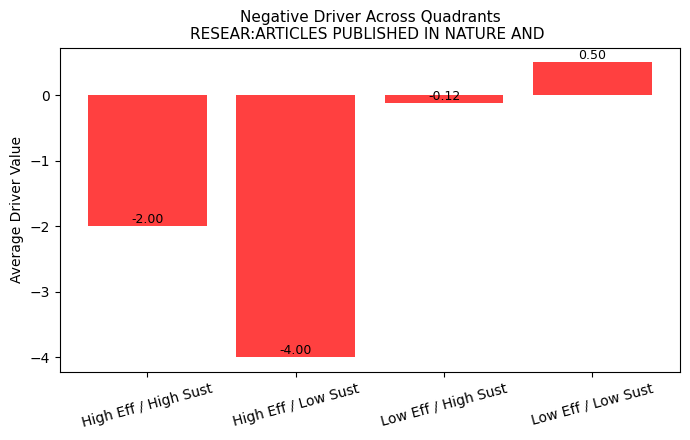

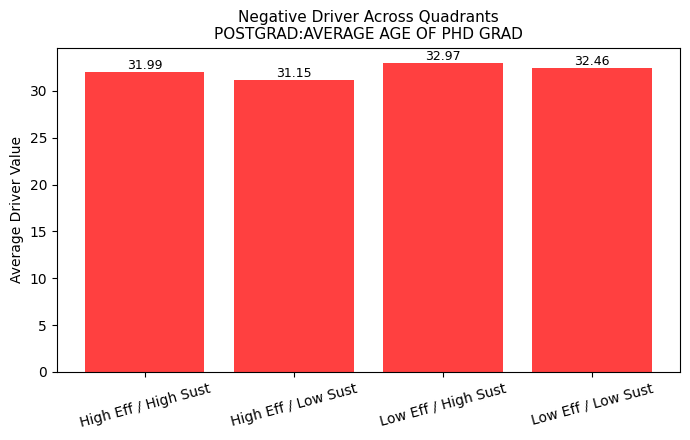

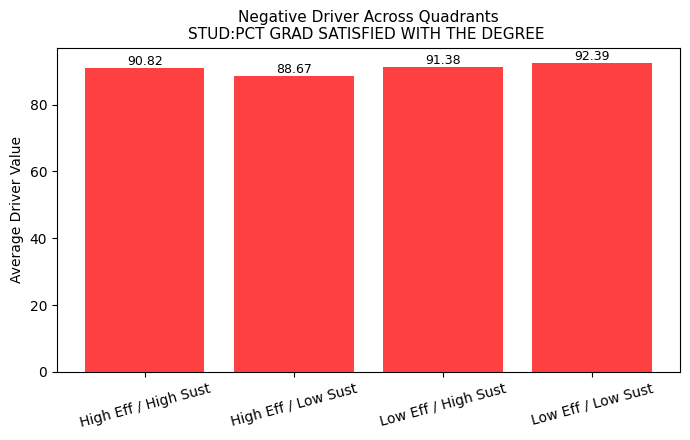

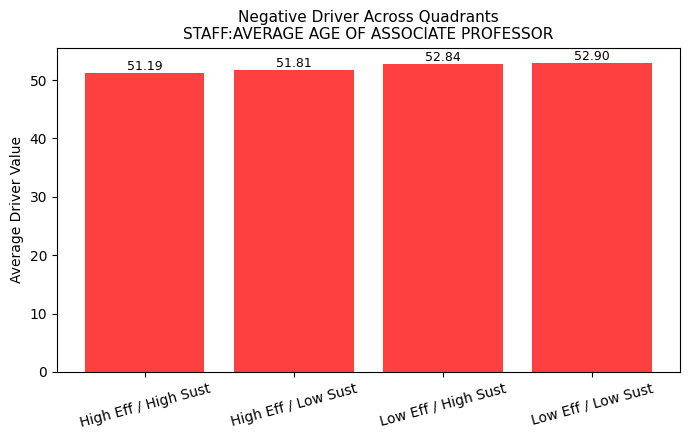

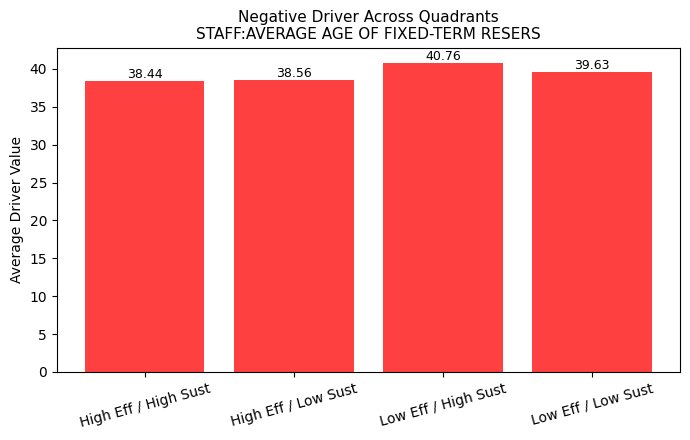

In [179]:
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# FIX DRIVER SCORE
# ==========================================

summary["driver_score"] = summary["driver_strength"]

# ==========================================
# TOP 5 POSITIVE / NEGATIVE
# ==========================================

top5_positive = (
    summary[summary["driver_strength"] > 0]
    .sort_values("abs_strength", ascending=False)
    .head(5)
)

top5_negative = (
    summary[summary["driver_strength"] < 0]
    .sort_values("abs_strength", ascending=False)
    .head(5)
)

# ==========================================
# COMBINE
# ==========================================

top_drivers = pd.concat([
    top5_positive.assign(Direction="Positive"),
    top5_negative.assign(Direction="Negative")
])

# ==========================================
# OPTIONAL NORMALISATION
# ==========================================

# uncomment if desired
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# driver_cols = top_drivers["Efficiency_Metric"].unique()
# dfFinal[driver_cols] = scaler.fit_transform(dfFinal[driver_cols])

# ==========================================
# LOOP THROUGH DRIVERS
# ==========================================

for _, row in top_drivers.iterrows():

    driver = row["Efficiency_Metric"]
    direction = row["Direction"]

    if driver not in dfFinal.columns:
        continue

    # --------------------------------------
    # Quadrant means
    # --------------------------------------

    quad_means = (
        dfFinal
        .groupby("QUADRANT")[driver]
        .mean()
        .reindex([
            "High Eff / High Sust",
            "High Eff / Low Sust",
            "Low Eff / High Sust",
            "Low Eff / Low Sust"
        ])
    )

    # --------------------------------------
    # Colour
    # --------------------------------------

    color = "green" if direction == "Positive" else "red"

    # --------------------------------------
    # Pretty title
    # --------------------------------------

    short_title = shorten_metric(driver)

    # --------------------------------------
    # Plot
    # --------------------------------------

    plt.figure(figsize=(7, 4.5))

    bars = plt.bar(
        quad_means.index,
        quad_means.values,
        color=color,
        alpha=0.75
    )

    # value labels
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.ylabel("Average Driver Value")

    plt.title(
        f"{direction} Driver Across Quadrants\n{short_title}",
        fontsize=11
    )

    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

In [180]:
import os
import re
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# CREATE OUTPUT FOLDER (Downloads/Driver outputs)
# ==========================================

output_dir = os.path.expanduser("~/Downloads/Driver outputs")
os.makedirs(output_dir, exist_ok=True)

# Save the drivers table too (useful for reporting)
top_drivers.to_csv(os.path.join(output_dir, "top_drivers.csv"), index=False)

# ==========================================
# LOOP THROUGH DRIVERS + SAVE FIGURES
# ==========================================

for _, row in top_drivers.iterrows():

    driver = row["Efficiency_Metric"]
    direction = row["Direction"]

    if driver not in dfFinal.columns:
        continue

    quad_means = (
        dfFinal
        .groupby("QUADRANT")[driver]
        .mean()
        .reindex([
            "High Eff / High Sust",
            "High Eff / Low Sust",
            "Low Eff / High Sust",
            "Low Eff / Low Sust"
        ])
    )

    color = "green" if direction == "Positive" else "red"
    short_title = shorten_metric(driver)

    plt.figure(figsize=(7, 4.5))

    bars = plt.bar(
        quad_means.index,
        quad_means.values,
        color=color,
        alpha=0.75
    )

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.ylabel("Average Driver Value")
    plt.title(f"{direction} Driver Across Quadrants\n{short_title}", fontsize=11)
    plt.xticks(rotation=15)
    plt.tight_layout()

    # ==========================================
    # SAFE FILENAME
    # ==========================================
    safe_name = re.sub(r"[^a-zA-Z0-9_\\-]", "_", driver)

    file_path = os.path.join(
        output_dir,
        f"{direction}_{safe_name}.png"
    )

    plt.savefig(file_path, dpi=300, bbox_inches="tight")
    plt.close()